In [1]:
import pandas as pd
import MaxNLP
from pathlib import Path
from tqdm.auto import tqdm
import json
tqdm.pandas(desc="Applying")
%load_ext autoreload
%autoreload 2
    
from datetime import date
date_str = date.today().isoformat()

In [2]:
# Load the translated text sample (25 per country --> 250 samples)
df_t=pd.read_json("2025-03-03 Sample25_translated.json")

In [3]:
# Read the codebooks as Markdown

codebook_causes = Path("codebooks/2026-03-16 causes codebook.md").read_text(encoding="utf-8")
codebook_responses = Path("codebooks/2026-01-30 responses codebook.md").read_text(encoding="utf-8")
codebook_consequences = Path("codebooks/2026-04-08b consequences codebook.md").read_text(encoding="utf-8")
codebook_futures = Path("codebooks/2026-02-15 lessons codebook.md").read_text(encoding="utf-8")

# Convert Markdown to Json
codebook_causes_json=MaxNLP.markdown_to_json(codebook_causes)
codebook_responses_json = MaxNLP.markdown_to_json(codebook_responses)
codebook_consequences_json=MaxNLP.markdown_to_json(codebook_consequences)
codebook_futures_json=MaxNLP.markdown_to_json(codebook_futures)


# Get the code list for creating the json scheme.
codes_causes= [i["label"] for i in codebook_causes_json]
codes_responses = [i["label"] for i in codebook_responses_json]
codes_consequences = [i["label"] for i in codebook_consequences_json]
codes_futures = [i["label"] for i in codebook_futures_json]


## Important: Context window is set to 2000 = roughly 2000 words; larger codebooks require to change this.
codes_causes


['EU political actors',
 'National political actors',
 "Russia's war on Ukraine",
 'Over-reliance on renewable energy',
 'Over-reliance on fossil fuels',
 'Media actors',
 'High import dependency',
 'Uncontrollable natural disasters',
 'Other external factors',
 'Industry actors',
 'Ideology / structural explanations']

In [4]:
# Create the System prompt --> requires to create a new client when changing the codebook.

codebook_md=json.dumps(codebook_consequences_json, indent=2, ensure_ascii=False)

PROMPTBOOK_INSTRUCTIONS = """
You are helpful qualitative research assistant coding short citizen perceptions of the European energy crisis with a defined codebook. 
You only respond in correct json format. Task: For EACH label, output a confidence score (0.0 = impossible, 1.0 = certain). 
Multi-label allowed. Return JSON only, matching the schema exactly (no extra keys). 
Do not add any labels that are not in the schema.
This is your json-codebook:\n
""".strip()

In [5]:
# Load the Nebula Client
from dotenv import load_dotenv
import openAI_key

client=MaxNLP.create_client(client="Nebula", openAI_key=openAI_key)
available_models = MaxNLP.get_nebula_models(client)

print(f"Models: {available_models}\n\n")

run_x=1

Nebula client loaded
Models: ['deepseek-r1:8b', 'deepseek-r1:1.5b', 'SURF.default-text-large', 'FAST.gemma3:12b', 'FAST.gpt-oss:120b', 'FAST.gpt-oss:20b', 'go-assist', 'research-railway-guide', 'SURF.Qwen 2.5 Coder 32B Instruct AWQ', 'SURF.Qwen 2.5 VL 32B Instruct AWQ', 'vu-rdm-support-chatbot---test', 'translategemma:12b', 'SURF.Mistral-Small-3.2-24B-Instruct-2506', 'SURF.gpt-oss-120b', 'llama3.1:8b']




In [6]:
# Run the LLM coding in a for-loop

codebook_name="causes"

import pandas as pd
import jsonlines
from pathlib import Path

for run_x in range(1):

    # Split the set in batches (to rerun not all of them when there is an error)
    tmp = df_t.reset_index(names="orig_index")
    tmp["batch_row"] = range(len(tmp))

    # Send the API request to the LLM; format everything with my module.
    # Write each result as new line to the temp  batch files 
    res = tmp.progress_apply(
        lambda r: MaxNLP.code_text(
            r["full_response"], r.orig_index, r.batch_row,
            client=client,
            model="FAST.gpt-oss:120b",
            code_list=codes_causes,
            PROMPTBOOK_INSTRUCTIONS=PROMPTBOOK_INSTRUCTIONS+json.dumps(codebook_causes_json),
            temperature=0.0,
            force_json_object=False,run_x=run_x
        ),
        axis=1,
    )

    # Combine the batch files to one json file
    ann_df = pd.DataFrame(x for f in Path("annotations_tmp").glob(f"{date_str} run_{run_x}_{codebook_name}_batch_*.jsonl") for x in jsonlines.open(f)).pipe(
        lambda d: pd.json_normalize(d["annotation"])
        .set_index(d["orig_index"]))
    
    # Writes the full run to one json file
    ann_df.reset_index().to_json(f"{date_str} {codebook_name}_run_{run_x}.json", orient="records")


Applying:   0%|          | 0/2 [00:00<?, ?it/s]

# Evaluation

Industry actors                       0.005333
Uncontrollable natural disasters      0.007000
Other external factors                0.007000
Russia's war on Ukraine               0.008000
Media actors                          0.008333
Over-reliance on fossil fuels         0.012667
Over-reliance on renewable energy     0.013667
EU political actors                   0.018667
High import dependency                0.036333
Ideology / structural explanations    0.037667
National political actors             0.070667
dtype: float64


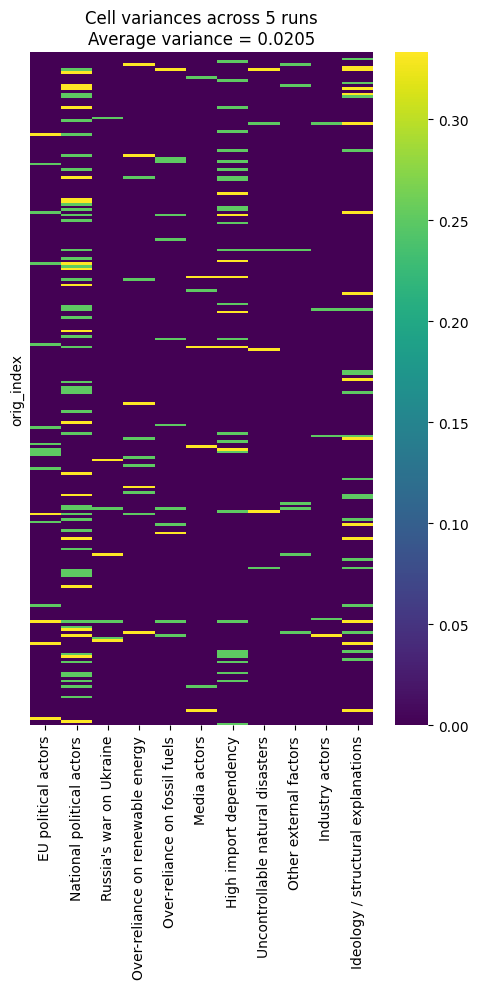

<Axes: >

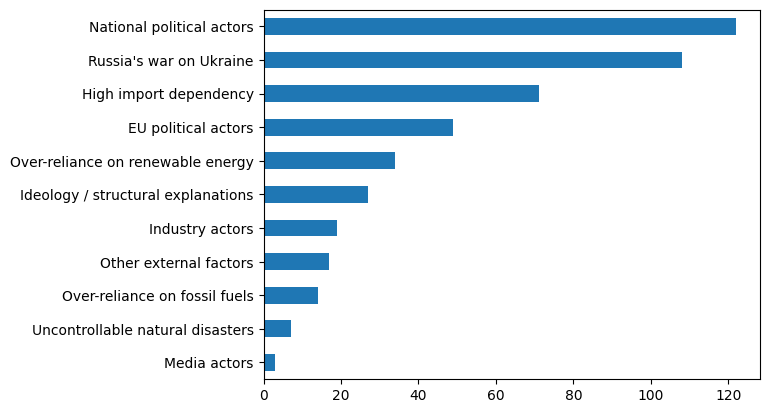

In [14]:
# Check Variation --> indicated stability of LLM runs.

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

x = pd.concat(
    [pd.read_json(f"2026-04-08 causes_run_{i}.json").set_index("orig_index").ge(0.5).astype(int) for i in range(4)],
    keys=range(4), names=["run"])

cell_var = x.groupby("orig_index").var()
avg_var = cell_var.mean().mean()

item_avg_var = cell_var.mean().sort_values()

print(item_avg_var)
plt.figure(figsize=(5, 10))
sns.heatmap(cell_var, cmap="viridis", yticklabels=False)
plt.title(f"Cell variances across 5 runs\nAverage variance = {avg_var:.4f}")
plt.tight_layout()
plt.show()

#x_mode = x.groupby("orig_index").agg(lambda s: s.mode().tolist())
x_mode = x.groupby("orig_index").agg(lambda s: s.mode().iat[0])
x_mode.sum().sort_values().sort_values().plot.barh()


C:\Users\mr\AppData\Local\Temp\ipykernel_26768\821757146.py:14: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


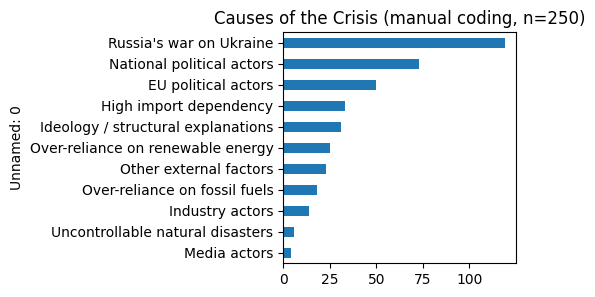

In [19]:
#Load Manual coding as gold standard

Annotation=pd.read_excel("MANUAL CODING/2026-03-16 CAUSES Manual Annotation FILLED.xlsx", sheet_name="Sheet1",header=0).T
Annotation.columns=Annotation.iloc[0,:]
Text=Annotation.iloc[1:,-4]
Annotation=Annotation.iloc[1:,:-4] # remove the text, translation, and notex

n_samples=Annotation.shape[0]

import matplotlib.pyplot as plt

s1 = Annotation.sum().sort_values()
s1.plot.barh(title=f"Causes of the Crisis (manual coding, n={n_samples})" , figsize=(3,3))
plt.tight_layout()
plt.show()
pd.set_option('display.max_colwidth', None)  # or a large number like 1000



In [16]:
merged = pd.concat(
    [x_mode.set_axis(x_mode.index.astype(int)).add_prefix("ai_"),
     Annotation.set_axis(Annotation.index.astype(int)).add_prefix("manual_")],
    axis=1,
    join="inner"
)

merged

,ai_EU political actors,ai_National political actors,ai_Russia's war on Ukraine,ai_Over-reliance on renewable energy,ai_Over-reliance on fossil fuels,ai_Media actors,ai_High import dependency,ai_Uncontrollable natural disasters,ai_Other external factors,ai_Industry actors,...,manual_National political actors,manual_Russia's war on Ukraine,manual_Over-reliance on renewable energy,manual_Over-reliance on fossil fuels,manual_Media actors,manual_High import dependency,manual_Uncontrollable natural disasters,manual_Other external factors,manual_Industry actors,manual_Ideology / structural explanations
82,1,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
110,0,0,1,0,0,0,1,0,0,0,...,0,1,0,0,0,0,0,0,0,0
138,0,1,1,1,0,0,1,0,0,0,...,0,1,1,0,0,0,0,0,0,0
151,1,0,0,0,1,0,1,0,0,0,...,0,1,0,1,0,0,0,0,0,0
181,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10287,0,0,1,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
10492,0,0,1,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
10500,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0
10504,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0


In [12]:
per_topic = MaxNLP.eval_ai_vs_manual(merged, question_list=x_mode.columns)
per_topic

,N,TP,FP,TN,FN,Precision,Recall,F1,Accuracy
EU political actors,250.0,25.0,25.0,176.0,24.0,0.500000,0.510204,0.505051,0.804
National political actors,250.0,56.0,17.0,111.0,66.0,0.767123,0.459016,0.574359,0.668
Russia's war on Ukraine,250.0,101.0,18.0,124.0,7.0,0.848739,0.935185,0.889868,0.900
Over-reliance on renewable energy,250.0,15.0,10.0,206.0,19.0,0.600000,0.441176,0.508475,0.884
Over-reliance on fossil fuels,250.0,6.0,12.0,224.0,8.0,0.333333,0.428571,0.375000,0.920
Media actors,250.0,0.0,4.0,243.0,3.0,0.000000,0.000000,0.000000,0.972
High import dependency,250.0,29.0,4.0,175.0,42.0,0.878788,0.408451,0.557692,0.816
Uncontrollable natural disasters,250.0,2.0,4.0,239.0,5.0,0.333333,0.285714,0.307692,0.964
Other external factors,250.0,15.0,8.0,225.0,2.0,0.652174,0.882353,0.750000,0.960
Industry actors,250.0,9.0,5.0,226.0,10.0,0.642857,0.473684,0.545455,0.940


In [13]:
text=df_t["full_response"].rename("text")
merged_t = merged.join(text)

out_path = f"{date_str} causes_False Positives.txt"

with open(out_path, "w", encoding="utf-8") as f:
    for col in x_mode.columns:
        ai_col = f"ai_{col}"
        manual_col = f"manual_{col}"

        mask = merged_t[ai_col].astype(int) != (merged_t[manual_col].astype(float) >= 0.5).astype(int)
        false_ones = merged_t.loc[mask, "text"]
        f.write(f"{col}:\n")
        for n, text in enumerate(false_ones, 1):
            f.write(f"  {n}. {str(text).strip()}\n")
        f.write("\n\n")

print(f"Written to {out_path}")

Written to 2026-04-09 causes_False Positives.txt
